  Detected Jupyter notebook - plots will be displayed inline

 A/B Evaluation - Interactive Mode

 Loading MinIO configuration...
Using MinIO configuration from environment variables: endpoint=localhost:9000, access_key=adm***

 Evaluation Settings:


  Test size (number of samples) [100]:  100


  Baseline model: openai/clip-vit-base-patch32 (fixed)

 Fine-Tuned Checkpoint:
  1. Use active checkpoint (from Checkpoint Manager)
  2. Select specific checkpoint
  3. Skip fine-tuned evaluation (baseline only)


  Choice [1]:  1


  Using active checkpoint: final_checkpoint

 Evaluation Summary:
  MinIO: localhost:9000
  Test Size: 100
  Baseline Model: openai/clip-vit-base-patch32
  Fine-Tuned Checkpoint: C:\Users\Arman\OneDrive\Desktop\sss\ADSDB\Arman_Bazarchi_ADSDB_Wildlife_Assist_Project\WildLife\Fine-Tuning-Zone\notebooks\../checkpoints\final_checkpoint


...


 Initializing fine-tuned model...
 Loading fine-tuned model from: C:\Users\Arman\OneDrive\Desktop\sss\ADSDB\Arman_Bazarchi_ADSDB_Wildlife_Assist_Project\WildLife\Fine-Tuning-Zone\checkpoints\final_checkpoint
 Loading base CLIP model...
 Loading LoRA adapters for text encoder from subdirectory...
 ✓ Loaded LoRA adapters for text encoder
 Loading LoRA adapters for vision encoder from subdirectory...
 ✓ Loaded LoRA adapters for vision encoder
 ✓ Fine-tuned model loaded successfully with LoRA adapters
   Text encoder: LoRA adapters active (r=16)
   Vision encoder: LoRA adapters active (r=16)
 Model moved to device: cpu

 Evaluating baseline model...
 Processing 100 samples for Baseline...


Evaluating Baseline: 100%|███████████████████████████████████████████████████████████| 100/100 [00:20<00:00,  4.84it/s]



 Evaluating fine-tuned model...
 Processing 100 samples for Fine-Tuned...


Evaluating Fine-Tuned: 100%|█████████████████████████████████████████████████████████| 100/100 [00:24<00:00,  4.14it/s]



 Evaluation Results

 Baseline Model Results:
------------------------------------------------------------
  Mean Similarity: 0.2801 ± 0.0308
  Top-1 Accuracy:  0.0800
  Top-5 Accuracy:  0.2600
  Top-10 Accuracy: 0.3700
  MRR:             0.1710

  Efficiency Metrics:
    Inference Time: 20.65s (206.46ms/sample)
    Total Parameters: 151,277,313
    Trainable Parameters: 151,277,313

 Fine-Tuned Model Results:
------------------------------------------------------------
  Mean Similarity: 0.2700 ± 0.0229
  Top-1 Accuracy:  0.1300
  Top-5 Accuracy:  0.4100
  Top-10 Accuracy: 0.5400
  MRR:             0.2949

  Efficiency Metrics:
    Inference Time: 24.18s (241.78ms/sample)
    Total Parameters: 153,243,393
    Trainable Parameters: 655,361

 Improvement:
------------------------------------------------------------
  Similarity:     -0.0101 (-3.61%)
  Top-1 Accuracy: +0.0500 (+62.50%)
  Top-5 Accuracy: +0.1500 (+57.69%)
  MRR:            +0.1239 (+72.46%)

  Efficiency Comparison:
    

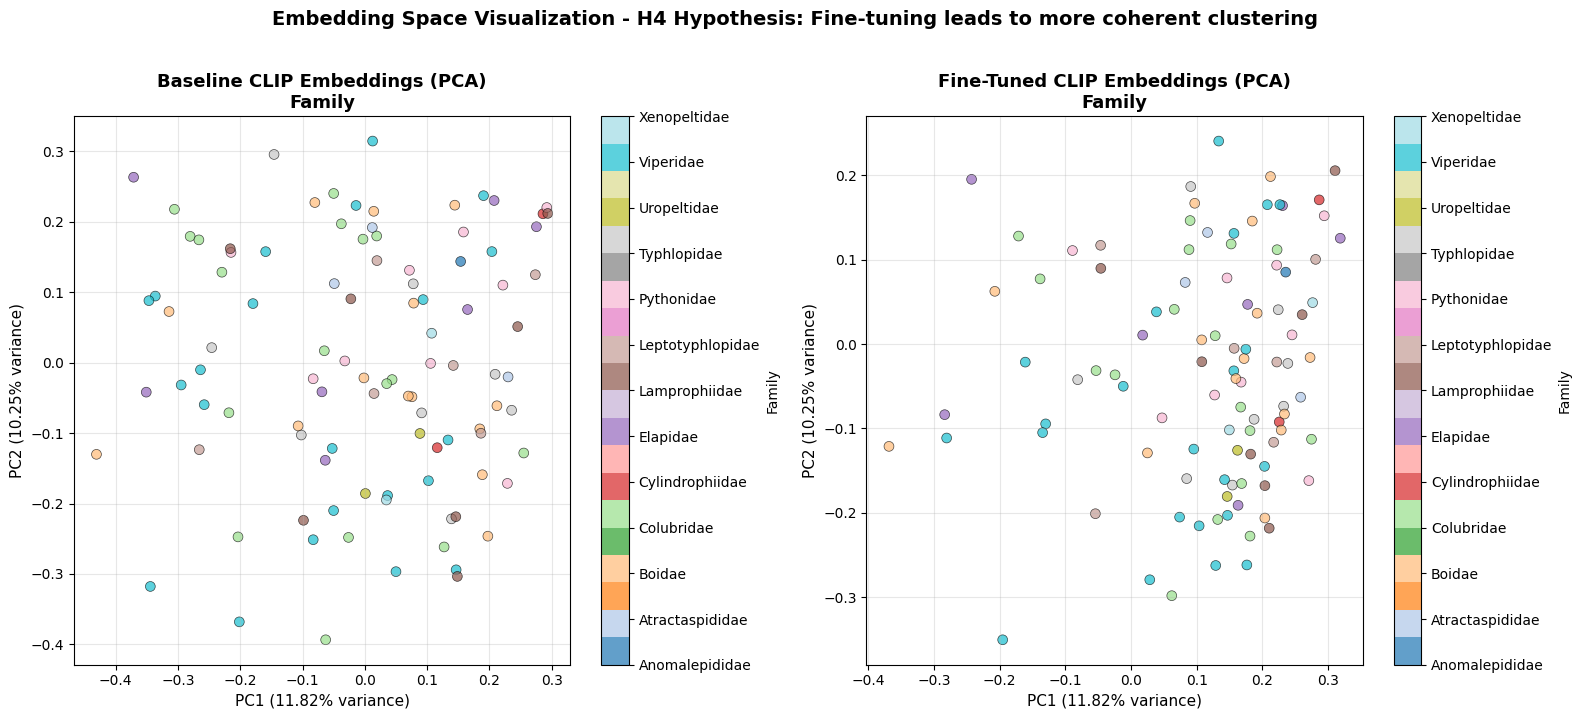

  ✓ Saved to MinIO: training-zone/evaluation_results/plots_20260105_030844/pca_embeddings_comparison.png

 Creating metrics comparison chart...


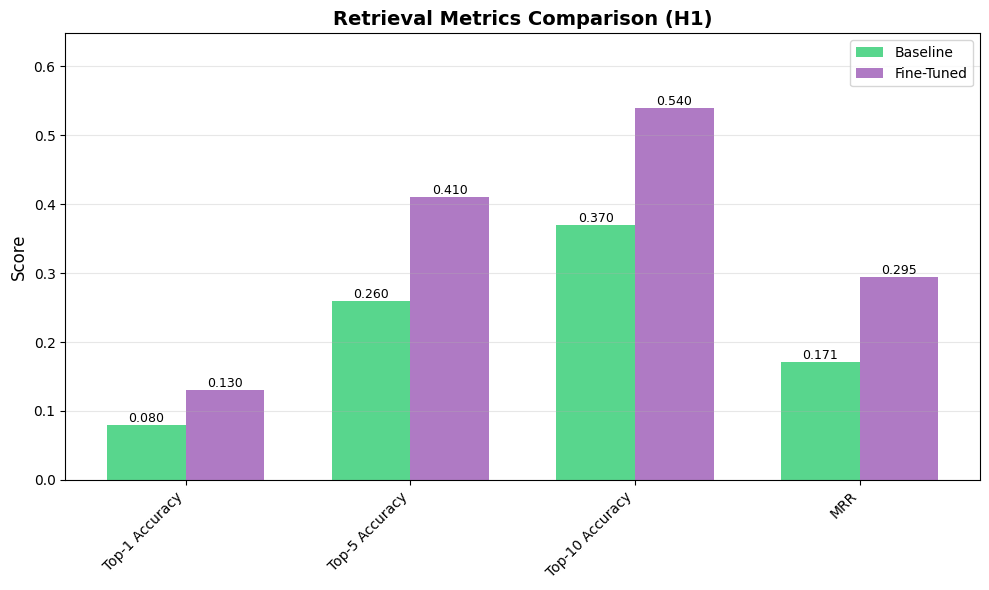

  ✓ Saved to MinIO: training-zone/evaluation_results/plots_20260105_030844/metrics_comparison.png

 Creating efficiency comparison chart...


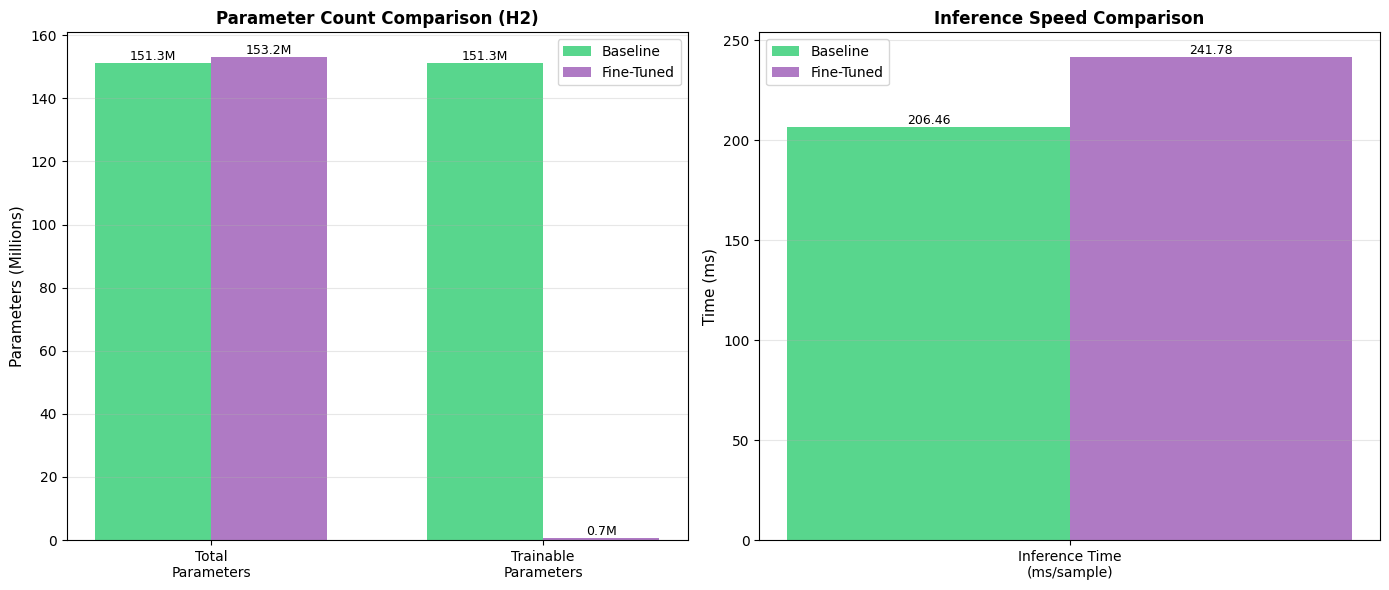

  ✓ Saved to MinIO: training-zone/evaluation_results/plots_20260105_030844/efficiency_comparison.png

 Interactive visualizations displayed and saved to: training-zone/evaluation_results/plots_20260105_030844

 Evaluation completed successfully!


In [1]:
"""
-Arman Bazarchi-
Fine-Tuning Zone — A/B Evaluation

This script performs A/B evaluation comparing baseline CLIP model with
fine-tuned checkpoints. It evaluates both models on the same test set
and compares their performance metrics.


RESEARCH HYPOTHESES 

H1: Fine-tuning CLIP with domain-specific wildlife data (snake species from 
    TreeOfLife-200M) improves multimodal image–text alignment and retrieval 
    performance compared to the original CLIP model.

H2: Parameter-efficient fine-tuning methods (LoRA and QLoRA) achieve comparable 
    retrieval performance to full-precision CLIP fine-tuning while significantly 
    reducing memory usage and number of trainable parameters.

H3: Fine-tuning leads to more coherent clustering of taxonomically related 
    species in the joint image–text embedding space.


EVALUATION METRICS 

Retrieval-Based Metrics (Primary):
- Top-k Accuracy (k=1, 5, 10): Measures whether the correct image–text pair 
  appears among the top k retrieved results. Essential for evaluating CLIP-style 
  retrieval tasks where users expect relevant results in the top-k list.
  
- Mean Reciprocal Rank (MRR): Captures ranking quality by penalizing cases where 
  the correct match appears lower in the retrieval list. Higher MRR indicates 
  better ranking of correct pairs.

- Mean Similarity: Measures the average cosine similarity between matching 
  image–text pairs. Higher similarity indicates stronger alignment between 
  modalities.

Computational Efficiency Metrics (Required):
- Inference Time: Total and per-sample inference time to measure model speed.
- Trainable Parameters: Number of parameters updated during fine-tuning 
  (LoRA/QLoRA adapters only).
- Total Parameters: Full model parameter count for comparison.
- GPU Memory Usage: Peak memory consumption during inference (if CUDA available).

EXPERIMENTAL DESIGN 

Controlled Conditions:
- Same test dataset and split for baseline and fine-tuned models
- Same processor and preprocessing pipeline
- Same similarity computation method
- Only model weights differ (baseline vs LoRA/QLoRA fine-tuned)

Baselines:
- Baseline: openai/clip-vit-base-patch32 (original, non-fine-tuned CLIP)
- Variants: LoRA fine-tuned CLIP, QLoRA fine-tuned CLIP

Reproducibility:
- Fixed random seed (42) for all random operations
- Deterministic data loading order
- Experiment configuration metadata saved with results
"""

import os
import json
import io
import random
import time
from datetime import datetime
from pathlib import Path
from typing import Dict, List, Tuple, Optional
import pandas as pd
import numpy as np
from PIL import Image
from minio import Minio
import torch
import torch.nn.functional as F
from tqdm import tqdm
from transformers import CLIPModel, CLIPProcessor, BitsAndBytesConfig
from peft import PeftModel

# Helper function to detect if running in Jupyter/IPython notebook
def is_notebook():
    # Detect if code is running in a Jupyter/IPython notebook.
    try:
        from IPython import get_ipython
        return get_ipython() is not None
    except Exception:
        return False

# Visualization imports
HAS_MATPLOTLIB = False
HEADLESS = False

try:
    import matplotlib
    import matplotlib.pyplot as plt
    import sys
    
    # Determine if we're in a headless environment
    # Windows doesn't have DISPLAY env var, so check platform
    is_windows = sys.platform.startswith('win')
    has_display = os.environ.get("DISPLAY", "") != ""
    
    # Headless = no DISPLAY on Unix/Linux AND not Windows AND not in a notebook
    # On Windows, try interactive backends even without DISPLAY
    if is_notebook():
        HEADLESS = False
        print("  Detected Jupyter notebook - plots will be displayed inline")
    elif is_windows:
        # Windows: try interactive backends (TkAgg is usually available)
        interactive_backends = ["TkAgg", "Qt5Agg"]
        backend_set = False
        
        for backend in interactive_backends:
            try:
                matplotlib.use(backend)
                backend_set = True
                HEADLESS = False
                print(f"  Using interactive backend: {backend} - plots will be displayed")
                break
            except:
                continue
        
        if not backend_set:
            # Fallback to Agg if no interactive backend works
            matplotlib.use("Agg")
            HEADLESS = True
            print("  No interactive backend available - visualizations will be saved only")
    elif has_display:
        # Unix/Linux with DISPLAY: try interactive backends
        interactive_backends = ["TkAgg", "Qt5Agg"]
        backend_set = False
        
        for backend in interactive_backends:
            try:
                matplotlib.use(backend)
                backend_set = True
                HEADLESS = False
                print(f"  Using interactive backend: {backend} - plots will be displayed")
                break
            except:
                continue
        
        if not backend_set:
            matplotlib.use("Agg")
            HEADLESS = True
            print("  No interactive backend available - visualizations will be saved only")
    else:
        # Unix/Linux without DISPLAY: headless environment
        matplotlib.use("Agg")
        HEADLESS = True
        print("  Detected headless environment - visualizations will be saved only")
    
    HAS_MATPLOTLIB = True

except ImportError:
    HAS_MATPLOTLIB = False
    HEADLESS = True
    print("Warning: matplotlib not available. Visualizations will be skipped.")

try:
    from sklearn.decomposition import PCA
    from sklearn.manifold import TSNE
    HAS_SKLEARN = True
except ImportError:
    HAS_SKLEARN = False
    print("Warning: sklearn not available. Embedding visualizations will be skipped.")

# -----------------------
#   Reproducibility (Constraint 9)
# -----------------------

def set_seed(seed=42):
    #cSet random seeds for reproducibility.
    # This ensures that experiments can be repeated with identical results,
    # addressing Constraint 9 requirements for reproducibility.
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        # For reproducibility with CUDA
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

# Set seed at module level for reproducibility
set_seed(42)

# -----------------------
#   Helper Functions (for Constraint 11)
# -----------------------

def _save_retrieval_examples(baseline_results, fine_tuned_results, results_path, minio_client=None):
    # Save retrieval examples for visualization to MinIO only.
    # Creates a separate JSON file with top-k retrieval examples that can be
    # used to visualize improvements in retrieval quality.
    # All results are stored exclusively in MinIO training-zone bucket.
    from datetime import datetime
    
    if minio_client is None:
        print("  Warning: MinIO client not provided. Cannot save retrieval examples.")
        return None
    
    try:
        # Extract timestamp from results_path
        if "/" in results_path:
            filename = results_path.split("/")[-1]
        else:
            filename = os.path.basename(results_path)
        timestamp = filename.replace("ab_evaluation_", "").replace(".json", "")
        examples_filename = f"retrieval_examples_{timestamp}.json"
        
        examples = {
            "baseline_examples": baseline_results.get("retrieval_examples", []) if baseline_results else [],
            "fine_tuned_examples": fine_tuned_results.get("retrieval_examples", []) if fine_tuned_results else [],
            "timestamp": datetime.now().isoformat()
        }
        
        training_zone = "training-zone"
        minio_path = f"evaluation_results/{examples_filename}"
        
        examples_json = json.dumps(examples, indent=2)
        examples_bytes = examples_json.encode('utf-8')
        
        minio_client.put_object(
            training_zone,
            minio_path,
            data=io.BytesIO(examples_bytes),
            length=len(examples_bytes),
            content_type="application/json"
        )
        
        print(f"  Retrieval examples saved to MinIO: {training_zone}/{minio_path}")
        return f"{training_zone}/{minio_path}"
        
    except Exception as e:
        print(f"  Warning: Could not save retrieval examples to MinIO: {e}")
        return None

def create_embedding_visualization_data(baseline_results, fine_tuned_results, output_path=None, minio_client=None):
    # Prepare embedding data for visualization (PCA/t-SNE/UMAP).
    # This function prepares the embedding data that can be used in a separate
    # notebook or script to create visualizations showing clustering improvements.
    # All results are stored exclusively in MinIO training-zone bucket.
    # Args:
    #     baseline_results: Results dictionary from baseline model evaluation
    #     fine_tuned_results: Results dictionary from fine-tuned model evaluation
    #     output_path: Filename to save visualization data JSON
    #     minio_client: MinIO client for saving to training-zone (required)
    # Returns:
    #     Dictionary with embeddings ready for dimensionality reduction
    from datetime import datetime
    
    viz_data = {
        "baseline_embeddings": {
            "image_embeddings": baseline_results.get("image_embeddings", []),
            "text_embeddings": baseline_results.get("text_embeddings", []),
        } if baseline_results else {},
        "fine_tuned_embeddings": {
            "image_embeddings": fine_tuned_results.get("image_embeddings", []),
            "text_embeddings": fine_tuned_results.get("text_embeddings", []),
        } if fine_tuned_results else {},
        "timestamp": datetime.now().isoformat(),
        "note": "Use this data with PCA, t-SNE, or UMAP to visualize embedding clustering (H3 hypothesis)"
    }
    
    if minio_client is None:
        print("  Warning: MinIO client not provided. Cannot save embedding visualization data.")
        return viz_data
    
    if not output_path:
        print("  Warning: No output path provided for embedding visualization data.")
        return viz_data
    
    try:
        training_zone = "training-zone"
        # Extract just the filename from output_path
        if "/" in output_path:
            viz_filename = output_path.split("/")[-1]
        else:
            viz_filename = os.path.basename(output_path) if os.path.basename(output_path) else output_path
        minio_path = f"evaluation_results/{viz_filename}"
        
        viz_json = json.dumps(viz_data, indent=2)
        viz_bytes = viz_json.encode('utf-8')
        
        minio_client.put_object(
            training_zone,
            minio_path,
            data=io.BytesIO(viz_bytes),
            length=len(viz_bytes),
            content_type="application/json"
        )
        
        print(f"  Embedding visualization data saved to MinIO: {training_zone}/{minio_path}")
        
    except Exception as e:
        print(f"  Warning: Could not save embedding viz to MinIO: {e}")
    
    return viz_data

# -----------------------
#   Interactive Visualization Functions (Constraint 11)
# -----------------------

def _create_interactive_visualizations(baseline_results, fine_tuned_results, results_path, test_data=None, minio_client=None):
    
    # Create and display interactive visualizations (Constraint 11 - Reporting).
    
    # Generates:
    # 1. PCA visualization with species/family color coding (H3 - Highest value)
    # 2. Baseline vs Fine-Tuned side-by-side comparison
    # 3. Metrics comparison charts
    # 4. Efficiency comparison charts
    
    # All plots are saved to MinIO training-zone/evaluation_results/plots/
    
    # This function automatically detects the environment:
    # - Interactive (local desktop/notebook): Shows plots inline
    # - Headless (Docker, CI, SSH): Saves to MinIO only
    
    # Args:
    #     baseline_results: Baseline model evaluation results
    #     fine_tuned_results: Fine-tuned model evaluation results
    #     results_path: Path/URI to results JSON file
    #     test_data: Test data with metadata (for species/family labels)
    #     minio_client: MinIO client for saving plots (required)
    
    # Returns:
    #     MinIO path prefix where plots are saved
    
    if not HAS_MATPLOTLIB:
        print(" Skipping visualizations: matplotlib not available")
        return None
    
    if minio_client is None:
        print(" Warning: MinIO client not provided. Cannot save visualizations.")
        return None
    
    if HEADLESS:
        print(" Note: Running in headless mode - plots will be saved to MinIO only")
    
    # Extract timestamp for organizing plots
    if "/" in results_path:
        filename = results_path.split("/")[-1]
    else:
        filename = os.path.basename(results_path)
    timestamp = filename.replace("ab_evaluation_", "").replace(".json", "")
    plots_prefix = f"evaluation_results/plots_{timestamp}"
    
    print(f" Creating visualizations in MinIO: training-zone/{plots_prefix}/")
    
    # 1. PCA visualization with species/family color coding (H3 - Highest value)
    if baseline_results and fine_tuned_results and test_data:
        print("\n Creating PCA visualization with species/family color coding...")
        _plot_pca_with_labels(baseline_results, fine_tuned_results, test_data, plots_prefix, minio_client)
    
    # 2. Metrics comparison chart
    if baseline_results and fine_tuned_results:
        print("\n Creating metrics comparison chart...")
        _plot_metrics_comparison(baseline_results, fine_tuned_results, plots_prefix, minio_client)
    
    # 3. Efficiency comparison chart
    if baseline_results and fine_tuned_results:
        print("\n Creating efficiency comparison chart...")
        _plot_efficiency_comparison(baseline_results, fine_tuned_results, plots_prefix, minio_client)
    
    return f"training-zone/{plots_prefix}"

def _plot_pca_with_labels(baseline_results, fine_tuned_results, test_data, plots_prefix, minio_client):
    
    # Create PCA visualization with species/family color coding (H3 hypothesis).
    
    # Shows baseline vs fine-tuned side-by-side with color coding by taxonomic labels.
    # This is the highest-value visualization for demonstrating improved clustering.
    
    # Saves plot to MinIO training-zone bucket.

    if not HAS_MATPLOTLIB or not HAS_SKLEARN:
        print("  Skipping PCA visualization: matplotlib or sklearn not available")
        return
    
    try:
        # Get embeddings
        baseline_img_emb = np.array(baseline_results.get('image_embeddings', []))
        fine_tuned_img_emb = np.array(fine_tuned_results.get('image_embeddings', []))
        
        if len(baseline_img_emb) == 0 or len(fine_tuned_img_emb) == 0:
            print("  Skipping PCA visualization: no embedding data available")
            return
        
        # Extract labels from test_data
        labels = []
        label_type = None
        
        for item in test_data[:len(baseline_img_emb)]:
            if 'family' in item and item.get('family'):
                labels.append(str(item['family']))
                if label_type is None:
                    label_type = 'family'
            elif 'species' in item and item.get('species'):
                labels.append(str(item['species']))
                if label_type is None:
                    label_type = 'species'
            elif 'genus' in item and item.get('genus'):
                labels.append(str(item['genus']))
                if label_type is None:
                    label_type = 'genus'
            else:
                labels.append('Unknown')
        
        # Convert labels to numeric for color mapping
        unique_labels = sorted(list(set(labels)))
        label_to_num = {label: i for i, label in enumerate(unique_labels)}
        numeric_labels = [label_to_num[label] for label in labels]
        
        # Apply PCA
        print(f"  Applying PCA to {len(baseline_img_emb)} embeddings...")
        pca = PCA(n_components=2)
        baseline_pca = pca.fit_transform(baseline_img_emb)
        fine_tuned_pca = pca.transform(fine_tuned_img_emb)
        
        # Create side-by-side comparison plot
        fig, axes = plt.subplots(1, 2, figsize=(16, 7))
        
        # Baseline
        ax1 = axes[0]
        scatter1 = ax1.scatter(
            baseline_pca[:, 0], baseline_pca[:, 1], 
            c=numeric_labels, cmap='tab20', alpha=0.7, s=50,
            edgecolors='black', linewidths=0.5
        )
        ax1.set_title(f'Baseline CLIP Embeddings (PCA)\n{label_type.capitalize() if label_type else "Labels"}', 
                     fontsize=13, fontweight='bold')
        ax1.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=11)
        ax1.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=11)
        ax1.grid(alpha=0.3)
        cbar1 = plt.colorbar(scatter1, ax=ax1, label=f'{label_type.capitalize() if label_type else "Class"}')
        if len(unique_labels) <= 20:
            cbar1.set_ticks(range(len(unique_labels)))
            cbar1.set_ticklabels(unique_labels)
        else:
            cbar1.set_label(f'{label_type.capitalize() if label_type else "Class"} (20+ categories)')
        
        # Fine-tuned
        ax2 = axes[1]
        scatter2 = ax2.scatter(
            fine_tuned_pca[:, 0], fine_tuned_pca[:, 1], 
            c=numeric_labels, cmap='tab20', alpha=0.7, s=50,
            edgecolors='black', linewidths=0.5
        )
        ax2.set_title(f'Fine-Tuned CLIP Embeddings (PCA)\n{label_type.capitalize() if label_type else "Labels"}', 
                     fontsize=13, fontweight='bold')
        ax2.set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.2f}% variance)', fontsize=11)
        ax2.set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.2f}% variance)', fontsize=11)
        ax2.grid(alpha=0.3)
        cbar2 = plt.colorbar(scatter2, ax=ax2, label=f'{label_type.capitalize() if label_type else "Class"}')
        if len(unique_labels) <= 20:
            cbar2.set_ticks(range(len(unique_labels)))
            cbar2.set_ticklabels(unique_labels)
        else:
            cbar2.set_label(f'{label_type.capitalize() if label_type else "Class"} (20+ categories)')
        
        plt.suptitle('Embedding Space Visualization - H3 Hypothesis: Fine-tuning leads to more coherent clustering', 
                    fontsize=14, fontweight='bold', y=1.02)
        plt.tight_layout()
        
        # Show plot if not headless (notebook or interactive terminal)
        if not HEADLESS:
            print("  Displaying PCA visualization...")
            plt.show()
        
        # Save to MinIO
        _save_plot_to_minio(fig, f"{plots_prefix}/pca_embeddings_comparison.png", minio_client)
        
        if HEADLESS:
            plt.close(fig)
        
    except Exception as e:
        print(f"  Error creating PCA visualization: {e}")
        import traceback
        traceback.print_exc()

def _save_plot_to_minio(fig, minio_path, minio_client):
    
    # Save a matplotlib figure to MinIO as PNG.
    
    # Args:
    #     fig: Matplotlib figure object
    #     minio_path: Path within training-zone bucket (e.g., "evaluation_results/plots_xxx/plot.png")
    #     minio_client: MinIO client instance

    # if minio_client is None:
    #  print(f"  Warning: MinIO client not provided. Cannot save {minio_path}")
    #  return
    
    try:
        training_zone = "training-zone"
        
        # Save figure to bytes buffer
        img_buffer = io.BytesIO()
        fig.savefig(img_buffer, format='png', dpi=300, bbox_inches='tight')
        img_buffer.seek(0)
        
        # Upload to MinIO
        minio_client.put_object(
            training_zone,
            minio_path,
            data=img_buffer,
            length=img_buffer.getbuffer().nbytes,
            content_type="image/png"
        )
        
        print(f"  Saved to MinIO: {training_zone}/{minio_path}")
        
    except Exception as e:
        print(f"  Warning: Could not save plot to MinIO: {e}")


def _plot_metrics_comparison(baseline_results, fine_tuned_results, plots_prefix, minio_client):
    # Create metrics comparison bar chart and save to MinIO.
    if not HAS_MATPLOTLIB:
        return
    
    metrics = ['Top-1 Accuracy', 'Top-5 Accuracy', 'Top-10 Accuracy', 'MRR']
    baseline_values = [
        baseline_results.get('top1_accuracy', 0),
        baseline_results.get('top5_accuracy', 0),
        baseline_results.get('top10_accuracy', 0),
        baseline_results.get('mrr', 0)
    ]
    fine_tuned_values = [
        fine_tuned_results.get('top1_accuracy', 0),
        fine_tuned_results.get('top5_accuracy', 0),
        fine_tuned_results.get('top10_accuracy', 0),
        fine_tuned_results.get('mrr', 0)
    ]
    
    x = np.arange(len(metrics))
    width = 0.35
    
    fig, ax = plt.subplots(figsize=(10, 6))
    bars1 = ax.bar(x - width/2, baseline_values, width, label='Baseline', alpha=0.8, color='#2ecc71')
    bars2 = ax.bar(x + width/2, fine_tuned_values, width, label='Fine-Tuned', alpha=0.8, color='#9b59b6')
    
    ax.set_ylabel('Score', fontsize=12)
    ax.set_title('Retrieval Metrics Comparison (H1)', fontsize=14, fontweight='bold')
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, rotation=45, ha='right')
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    ax.set_ylim([0, max(max(baseline_values), max(fine_tuned_values)) * 1.2])
    
    # Add value labels on bars
    for bars in [bars1, bars2]:
        for bar in bars:
            height = bar.get_height()
            ax.text(bar.get_x() + bar.get_width()/2., height,
                   f'{height:.3f}',
                   ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    # Show plot if not headless (notebook or interactive terminal)
    if not HEADLESS:
        plt.show()

    # Save to MinIO
    _save_plot_to_minio(fig, f"{plots_prefix}/metrics_comparison.png", minio_client)

    if HEADLESS:
        plt.close(fig)

def _plot_efficiency_comparison(baseline_results, fine_tuned_results, plots_prefix, minio_client):
    # Create efficiency metrics comparison chart and save to MinIO.
    if not HAS_MATPLOTLIB:
        return
    
    if 'trainable_params' not in baseline_results or 'trainable_params' not in fine_tuned_results:
        return
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6))
    
    # Parameter comparison
    ax1 = axes[0]
    param_labels = ['Total\nParameters', 'Trainable\nParameters']
    baseline_params = [
        baseline_results.get('total_params', 0) / 1e6,
        baseline_results.get('trainable_params', 0) / 1e6
    ]
    fine_tuned_params = [
        fine_tuned_results.get('total_params', 0) / 1e6,
        fine_tuned_results.get('trainable_params', 0) / 1e6
    ]
    
    x = np.arange(len(param_labels))
    width = 0.35
    ax1.bar(x - width/2, baseline_params, width, label='Baseline', alpha=0.8, color='#2ecc71')
    ax1.bar(x + width/2, fine_tuned_params, width, label='Fine-Tuned', alpha=0.8, color='#9b59b6')
    ax1.set_ylabel('Parameters (Millions)', fontsize=11)
    ax1.set_title('Parameter Count Comparison (H2)', fontsize=12, fontweight='bold')
    ax1.set_xticks(x)
    ax1.set_xticklabels(param_labels)
    ax1.legend()
    ax1.grid(axis='y', alpha=0.3)
    
    # Add value labels
    for i, (b, f) in enumerate(zip(baseline_params, fine_tuned_params)):
        ax1.text(i - width/2, b, f'{b:.1f}M', ha='center', va='bottom', fontsize=9)
        ax1.text(i + width/2, f, f'{f:.1f}M', ha='center', va='bottom', fontsize=9)
    
    # Inference time comparison
    ax2 = axes[1]
    if 'avg_inference_time_per_sample_sec' in baseline_results and 'avg_inference_time_per_sample_sec' in fine_tuned_results:
        time_labels = ['Inference Time\n(ms/sample)']
        baseline_time = [baseline_results.get('avg_inference_time_per_sample_sec', 0) * 1000]
        fine_tuned_time = [fine_tuned_results.get('avg_inference_time_per_sample_sec', 0) * 1000]
        
        x = np.arange(len(time_labels))
        ax2.bar(x - width/2, baseline_time, width, label='Baseline', alpha=0.8, color='#2ecc71')
        ax2.bar(x + width/2, fine_tuned_time, width, label='Fine-Tuned', alpha=0.8, color='#9b59b6')
        ax2.set_ylabel('Time (ms)', fontsize=11)
        ax2.set_title('Inference Speed Comparison', fontsize=12, fontweight='bold')
        ax2.set_xticks(x)
        ax2.set_xticklabels(time_labels)
        ax2.legend()
        ax2.grid(axis='y', alpha=0.3)
        
        # Add value labels
        ax2.text(0 - width/2, baseline_time[0], f'{baseline_time[0]:.2f}', ha='center', va='bottom', fontsize=9)
        ax2.text(0 + width/2, fine_tuned_time[0], f'{fine_tuned_time[0]:.2f}', ha='center', va='bottom', fontsize=9)
    
    plt.tight_layout()
    
    # Show plot if not headless (notebook or interactive terminal)
    if not HEADLESS:
        plt.show()

    # Save to MinIO
    _save_plot_to_minio(fig, f"{plots_prefix}/efficiency_comparison.png", minio_client)

    if HEADLESS:
        plt.close(fig)

# -----------------------
#      Configuration
# -----------------------

def evaluate_ab_comparison(
    minio_host="localhost:9000",
    access_key="admin",
    secret_key="password123",
    test_size=100,
    baseline_model_name="openai/clip-vit-base-patch32",
    fine_tuned_checkpoint_path=None):
    # Perform A/B evaluation comparing baseline and fine-tuned models.
    # Args:
    #     minio_host: MinIO endpoint
    #     access_key: MinIO access key
    #     secret_key: MinIO secret key
    #     test_size: Number of test samples to evaluate
    #     baseline_model_name: Baseline Hugging Face CLIP model name (e.g., "openai/clip-vit-base-patch32")
    #     fine_tuned_checkpoint_path: Path to fine-tuned checkpoint (None uses active checkpoint)

    
    print("=" * 60)
    print(" A/B Evaluation: Baseline vs Fine-Tuned CLIP")
    print("=" * 60)
    
    # Initialize MinIO client for saving results to training-zone
    minio_client = Minio(minio_host, access_key=access_key, secret_key=secret_key, secure=False)
    
    # Load test data from trusted-zone
    print("\n Loading test data from trusted-zone...")
    test_data = _load_test_data(minio_host, access_key, secret_key, test_size)
    
    if len(test_data) == 0:
        raise SystemExit(" No test data found. Cannot perform evaluation.")
    
    print(f" Loaded {len(test_data)} test samples")
    
    # Initialize baseline model
    print("\n Initializing baseline model...")
    baseline_model, baseline_processor = _initialize_baseline_model(baseline_model_name)
    
    # Initialize fine-tuned model
    print("\n Initializing fine-tuned model...")
    if fine_tuned_checkpoint_path is None:
        fine_tuned_checkpoint_path = _get_active_checkpoint_path()
    
    if fine_tuned_checkpoint_path and os.path.exists(fine_tuned_checkpoint_path):
        fine_tuned_model, fine_tuned_processor = _initialize_finetuned_model(
            fine_tuned_checkpoint_path, baseline_model_name
        )
    else:
        print(" Warning: No fine-tuned checkpoint found. Skipping fine-tuned evaluation.")
        fine_tuned_model = None
    
    # Evaluate baseline
    print("\n Evaluating baseline model...")
    baseline_results = _evaluate_model(
        baseline_model, baseline_processor,
        test_data, minio_host, access_key, secret_key, "Baseline"
    )
    
    # Evaluate fine-tuned if available
    fine_tuned_results = None
    if fine_tuned_model:
        print("\n Evaluating fine-tuned model...")
        fine_tuned_results = _evaluate_model(
            fine_tuned_model, fine_tuned_processor,
            test_data, minio_host, access_key, secret_key, "Fine-Tuned"
        )
    
    # Compare results
    print("\n" + "=" * 60)
    print(" Evaluation Results")
    print("=" * 60)
    
    _display_results(baseline_results, fine_tuned_results)
    
    # Save results to MinIO training-zone/evaluation_results/ (Constraint 9)
    results_path = _save_results(
        baseline_results, 
        fine_tuned_results,
        fine_tuned_checkpoint_path=fine_tuned_checkpoint_path,
        baseline_model_name=baseline_model_name,
        minio_client=minio_client
    )
    print(f"\n Results saved to: {results_path}")
    
    # Save retrieval examples to MinIO (Constraint 11)
    if fine_tuned_results and 'retrieval_examples' in fine_tuned_results:
        _save_retrieval_examples(baseline_results, fine_tuned_results, results_path, minio_client=minio_client)
    
    # Save embedding data for visualization to MinIO
    try:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
        viz_data_path = f"embedding_viz_{timestamp}.json"
        create_embedding_visualization_data(baseline_results, fine_tuned_results, viz_data_path, minio_client=minio_client)
    except Exception as e:
        print(f" Note: Could not save embedding visualization data: {e}")
    
    # Generate interactive visualizations and save to MinIO
    if baseline_results and fine_tuned_results:
        plots_path = _create_interactive_visualizations(
            baseline_results,
            fine_tuned_results,
            results_path,
            test_data=test_data,
            minio_client=minio_client
        )
        if plots_path:
            if not HEADLESS:
                print(f"\n Interactive visualizations displayed and saved to: {plots_path}")
            else:
                print(f"\n Visualizations saved to MinIO: {plots_path}")

def _load_training_uuids(minio_host, access_key, secret_key):
    # Load UUIDs of training data from training-zone bucket.
    # This ensures test data does not overlap with training data.
    # Args:
    #     minio_host: MinIO endpoint
    #     access_key: MinIO access key
    #     secret_key: MinIO secret key
    # Returns:
    #     Set of UUIDs used for training
    training_zone = "training-zone"
    training_uuids = set()
    
    try:
        client = Minio(minio_host, access_key=access_key, secret_key=secret_key, secure=False)
        
        # Check if training-zone exists
        if not client.bucket_exists(training_zone):
            print(f"  Training zone '{training_zone}' does not exist. No training UUIDs to exclude.")
            return training_uuids
        
        # Load metadata from training-zone
        metadata_objs = [
            obj.object_name for obj in client.list_objects(training_zone, prefix="metadata/", recursive=True)
            if obj.object_name.lower().endswith(".csv")
        ]
        
        if not metadata_objs:
            print(f"  No metadata found in {training_zone}. No training UUIDs to exclude.")
            return training_uuids
        
        # Get the latest metadata file
        metadata_objs.sort(reverse=True)
        latest_meta = metadata_objs[0]
        
        resp = client.get_object(training_zone, latest_meta)
        data = resp.read()
        resp.close()
        resp.release_conn()
        training_metadata_df = pd.read_csv(io.BytesIO(data))
        
        # Extract all UUIDs
        for _, row in training_metadata_df.iterrows():
            uuid_val = row.get('uuid')
            if not pd.isna(uuid_val):
                training_uuids.add(str(uuid_val))
        
        print(f"  Loaded {len(training_uuids)} training UUIDs from {training_zone}")
        
    except Exception as e:
        print(f"  Warning: Could not load training UUIDs: {e}")
        print(f"  Proceeding without excluding training data (test may include training samples)")
    
    return training_uuids

def _load_test_data(minio_host, access_key, secret_key, test_size):
    
    # Load test data from trusted zone with balanced sampling across families.
    
    # - Ensures equal representation from each family. For example:
    # - If test_size=110 and there are 11 families, selects 10 observations per family
    # - If a family has fewer observations than requested, uses all available
    
    # Also excludes any observations that were used for training (by UUID check).
    
    # Args:
    #    minio_host: MinIO endpoint
    #     access_key: MinIO access key
    #     secret_key: MinIO secret key
    #     test_size: Total number of test samples to evaluate
    
    # Returns:
    #    List of test data dictionaries with balanced family representation
    client = Minio(minio_host, access_key=access_key, secret_key=secret_key, secure=False)
    trusted_zone = "trusted-zone"
    
    # Load training UUIDs to exclude from test data
    training_uuids = _load_training_uuids(minio_host, access_key, secret_key)
    
    print(f"  Loading from MinIO bucket: {trusted_zone}")
    
    # Load metadata from trusted-zone
    metadata_objs = [
        obj.object_name for obj in client.list_objects(trusted_zone, prefix="metadata/", recursive=True)
        if obj.object_name.lower().endswith(".csv")
    ]
    
    if not metadata_objs:
        return []
    
    metadata_objs.sort(reverse=True)
    latest_meta = metadata_objs[0]
    
    resp = client.get_object(trusted_zone, latest_meta)
    data = resp.read()
    resp.close()
    resp.release_conn()
    metadata_df = pd.read_csv(io.BytesIO(data))
    
    # Create text descriptions
    metadata_df['text'] = metadata_df.apply(_create_text_description, axis=1)
    
    # Get image paths from trusted-zone
    images_prefix = "images/"
    image_objects = list(client.list_objects(trusted_zone, prefix=images_prefix, recursive=True))
    print(f"  Found {len(image_objects)} images in {trusted_zone}")
    
    # Create image lookup by UUID for faster matching
    image_lookup = {}
    for obj in image_objects:
        if obj.object_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            # Extract UUID from filename (assuming format: uuid.jpg or path/uuid.jpg)
            filename = os.path.basename(obj.object_name)
            uuid_candidate = filename.split('.')[0]
            if uuid_candidate not in image_lookup:
                image_lookup[uuid_candidate] = obj.object_name
    
    # Build complete dataset with images (excluding training data)
    complete_data = []
    excluded_count = 0
    for _, row in metadata_df.iterrows():
        uuid_val = row.get('uuid')
        if pd.isna(uuid_val) or not row.get('text'):
            continue
        
        # Skip if this UUID was used for training
        uuid_str = str(uuid_val)
        if uuid_str in training_uuids:
            excluded_count += 1
            continue
        
        # Find corresponding image
        image_path = image_lookup.get(uuid_str)
        
        if image_path:
            family = str(row.get('family', '')).strip()
            if not family or family == 'nan' or family == '':
                family = 'Unknown'
            
            complete_data.append({
                'uuid': uuid_str,
                'image_path': image_path,
                'text': row['text'],
                'family': family,
                'genus': str(row.get('genus', '')).strip(),
                'species': str(row.get('species', '')).strip(),
                'scientific_name': str(row.get('scientific_name', '')).strip()
            })
    
    if excluded_count > 0:
        print(f"  Excluded {excluded_count} observations that were used for training")
    
    if not complete_data:
        return []
    
    # Group by family
    family_groups = {}
    for item in complete_data:
        family = item['family']
        if family not in family_groups:
            family_groups[family] = []
        family_groups[family].append(item)
    
    # Calculate samples per family
    num_families = len(family_groups)
    if num_families == 0:
        return []
    
    samples_per_family = test_size // num_families
    remainder = test_size % num_families
    
    print(f"  Found {num_families} families in dataset")
    print(f"  Target: {samples_per_family} observations per family")
    if remainder > 0:
        print(f"  Note: {remainder} extra observations will be distributed across families")
    
    # Sample equally from each family, then fill missing from other families
    test_data = []
    family_counts = {}
    sampled_uuids = set()  # Track all sampled UUIDs to avoid duplicates
    
    # First pass: sample equally from each family
    for family, items in family_groups.items():
        available = len(items)
        requested = samples_per_family
        
        if available >= requested:
            # Sample requested amount
            sampled = random.sample(items, requested)
            test_data.extend(sampled)
            family_counts[family] = requested
            sampled_uuids.update(item['uuid'] for item in sampled)
        else:
            # Use all available if family has fewer than requested
            test_data.extend(items)
            family_counts[family] = available
            sampled_uuids.update(item['uuid'] for item in items)
            print(f"    Warning: Family '{family}' has only {available} observations (requested {requested})")
    
    # Calculate how many observations are still needed
    observations_needed = test_size - len(test_data)
    
    # Second pass: fill missing observations from other families
    if observations_needed > 0:
        print(f"  Collected {len(test_data)} observations, need {observations_needed} more")
        print(f"  Filling missing observations from families with available data...")
        
        # Collect all available items from all families that haven't been sampled yet
        available_items_pool = []
        for family, items in family_groups.items():
            remaining_items = [item for item in items if item['uuid'] not in sampled_uuids]
            available_items_pool.extend(remaining_items)
        
        if available_items_pool:
            # Shuffle to randomize selection
            random.shuffle(available_items_pool)
            
            # Sample the needed amount
            to_sample = min(observations_needed, len(available_items_pool))
            additional_samples = available_items_pool[:to_sample]
            test_data.extend(additional_samples)
            sampled_uuids.update(item['uuid'] for item in additional_samples)
            
            # Update family counts for the additional samples
            for item in additional_samples:
                family = item['family']
                family_counts[family] = family_counts.get(family, 0) + 1
            
            if to_sample > 0:
                print(f"    Added {to_sample} additional observations from other families")
            
            if to_sample < observations_needed:
                print(f"    Warning: Only {to_sample} additional observations available (needed {observations_needed})")
        else:
            print(f"    Warning: No additional observations available to fill the gap")
    
    # Third pass: distribute remainder if we still have room
    if remainder > 0 and len(test_data) < test_size:
        # Get families that still have available observations
        families_with_extra = []
        for family, items in family_groups.items():
            already_sampled = family_counts.get(family, 0)
            available = len(items)
            if available > already_sampled:
                families_with_extra.append((family, available - already_sampled))
        
        # Distribute remainder across families with available observations
        if families_with_extra:
            # Shuffle to randomize which families get extra samples
            random.shuffle(families_with_extra)
            
            extra_needed = min(remainder, test_size - len(test_data))
            for family, available_extra in families_with_extra:
                if extra_needed <= 0:
                    break
                
                # Get items not yet sampled
                all_items = family_groups[family]
                remaining_items = [item for item in all_items if item['uuid'] not in sampled_uuids]
                
                if remaining_items:
                    to_sample = min(extra_needed, len(remaining_items))
                    sampled = random.sample(remaining_items, to_sample)
                    test_data.extend(sampled)
                    sampled_uuids.update(item['uuid'] for item in sampled)
                    family_counts[family] = family_counts.get(family, 0) + to_sample
                    extra_needed -= to_sample
    
    # Final check: if we still haven't reached the target, try one more time with all remaining data
    if len(test_data) < test_size:
        still_needed = test_size - len(test_data)
        # Collect ALL remaining items from ALL families
        all_remaining = []
        for family, items in family_groups.items():
            for item in items:
                if item['uuid'] not in sampled_uuids:
                    all_remaining.append(item)
        
        if all_remaining:
            random.shuffle(all_remaining)
            to_add = min(still_needed, len(all_remaining))
            final_additional = all_remaining[:to_add]
            test_data.extend(final_additional)
            sampled_uuids.update(item['uuid'] for item in final_additional)
            
            # Update family counts
            for item in final_additional:
                family = item['family']
                family_counts[family] = family_counts.get(family, 0) + 1
            
            if to_add > 0:
                print(f"    Final fill: Added {to_add} more observations (total now: {len(test_data)})")
    
    # Shuffle final test data to randomize order
    random.shuffle(test_data)
    
    # Limit to exact test_size if we oversampled
    if len(test_data) > test_size:
        test_data = test_data[:test_size]
    
    # Print summary
    print(f"  Final test set: {len(test_data)} observations")
    print(f"  Distribution by family:")
    for family in sorted(family_counts.keys()):
        count = family_counts[family]
        print(f"    {family}: {count} observations")
    
    return test_data

def _create_text_description(row):
    # Create text description from metadata row.
    def clean_value(value):
        return value if value and value != 'nan' and value != 'None' and value != '' else ''
    
    common_name = clean_value(str(row.get('common', '')).strip())
    scientific_name = clean_value(str(row.get('scientific_name', '')).strip())
    family = clean_value(str(row.get('family', '')).strip())
    genus = clean_value(str(row.get('genus', '')).strip())
    species = clean_value(str(row.get('species', '')).strip())
    kingdom = clean_value(str(row.get('kingdom', '')).strip())
    class_name = clean_value(str(row.get('class', '')).strip())
    
    description_parts = ["This life is"]
    
    if common_name:
        description_parts.append(f"commonly known as {common_name}")
    elif scientific_name:
        description_parts.append(f"scientifically named as {scientific_name}")
    else:
        description_parts.append("wildlife species")
    
    if scientific_name and scientific_name != common_name:
        description_parts.append(f"scientifically named as {scientific_name}")
    
    if kingdom:
        description_parts.append(f"in kingdom {kingdom}")
    if class_name:
        description_parts.append(f"in the {class_name} class")
    if family:
        description_parts.append(f"belonging to the {family} family")
    if genus:
        description_parts.append(f"genus {genus}")
    if species:
        description_parts.append(f"and species of {species}")
    
    return ' '.join(description_parts) + '.'

class VisionModelWrapper(torch.nn.Module):
    
    # Wrapper for vision model to filter kwargs while preserving LoRA functionality.
    
    # IMPORTANT: We do NOT override __call__ - let nn.Module handle it properly.
    # We filter kwargs in forward() and call the model with LoRA adapters active.
    
    #PEFT Structure:
    # - peft_model = PeftModelForFeatureExtraction (wrapper that adds unwanted kwargs)
    # - peft_model.base_model = LoraModel (adapter manager)
    # - peft_model.base_model.model = Original model with LoRA layers INJECTED
    
    # The LoRA layers are PART of peft_model.base_model.model, so calling it directly
    # still uses LoRA - we're just bypassing the PeftModelForFeatureExtraction wrapper
    # that adds input_ids to vision model calls.
    
    def __init__(self, peft_model):
        super().__init__()
        self.peft_model = peft_model
        # Copy important attributes
        if hasattr(peft_model, 'config'):
            self.config = peft_model.config
        
        # Get reference to the actual model with LoRA layers injected
        # This is the model that has LoRA adapters as part of its structure
        if hasattr(peft_model, 'base_model') and hasattr(peft_model.base_model, 'model'):
            self._lora_model = peft_model.base_model.model
        elif hasattr(peft_model, 'base_model'):
            self._lora_model = peft_model.base_model
        else:
            self._lora_model = peft_model
    
    def forward(self, *args, **kwargs):
        # Filter kwargs and call model with LoRA adapters active.
        # Extract pixel_values
        pixel_values = kwargs.get("pixel_values", None)
        if pixel_values is None and len(args) > 0:
            pixel_values = args[0]
        
        # Filter to only valid vision model arguments
        valid_kwargs = {}
        valid_keys = ['pixel_values', 'output_attentions', 'output_hidden_states', 
                     'interpolate_pos_encoding', 'return_dict']
        
        for key in valid_keys:
            if key in kwargs:
                valid_kwargs[key] = kwargs[key]
        
        if pixel_values is not None:
            valid_kwargs['pixel_values'] = pixel_values
        
        # Call the model with LoRA layers active
        # _lora_model is the original model with LoRA adapters injected into its layers
        # Using __call__ (not .forward()) to preserve PyTorch's hook system
        return self._lora_model(**valid_kwargs)

class TextModelWrapper(torch.nn.Module):
    # Wrapper for text model to filter kwargs while preserving LoRA functionality.
    
    # IMPORTANT: We do NOT override __call__ - let nn.Module handle it properly.
    # We filter kwargs in forward() and call the model with LoRA adapters active.

    def __init__(self, peft_model):
        super().__init__()
        self.peft_model = peft_model
        # Copy important attributes
        if hasattr(peft_model, 'config'):
            self.config = peft_model.config
        
        # Get reference to the actual model with LoRA layers injected
        if hasattr(peft_model, 'base_model') and hasattr(peft_model.base_model, 'model'):
            self._lora_model = peft_model.base_model.model
        elif hasattr(peft_model, 'base_model'):
            self._lora_model = peft_model.base_model
        else:
            self._lora_model = peft_model
    
    def forward(self, *args, **kwargs):
        # Filter kwargs and call model with LoRA adapters active.
        # Filter to only valid text model arguments
        valid_kwargs = {}
        valid_keys = ['input_ids', 'attention_mask', 'position_ids', 
                     'output_attentions', 'output_hidden_states', 'return_dict']
        
        for key in valid_keys:
            if key in kwargs:
                valid_kwargs[key] = kwargs[key]
        
        # Extract input_ids from args if not in kwargs
        if 'input_ids' not in valid_kwargs and len(args) > 0:
            valid_kwargs['input_ids'] = args[0]
        
        # Call the model with LoRA layers active
        # _lora_model is the original model with LoRA adapters injected into its layers
        # Using __call__ (not .forward()) to preserve PyTorch's hook system
        return self._lora_model(**valid_kwargs)

def _initialize_baseline_model(model_name):
    # Initialize baseline Hugging Face CLIP model.
    print(f" Loading baseline model: {model_name}")
    model = CLIPModel.from_pretrained(model_name)
    processor = CLIPProcessor.from_pretrained(model_name)
    model.eval()
    return model, processor

def _initialize_finetuned_model(checkpoint_path, model_name):
    # Initialize fine-tuned Hugging Face CLIP model from checkpoint with LoRA adapters.
    # Normalize the checkpoint path to resolve relative paths (e.g., ../checkpoints)
    checkpoint_path = os.path.normpath(os.path.abspath(checkpoint_path))
    print(f" Loading fine-tuned model from: {checkpoint_path}")
    
    # Check if QLoRA was used by reading training_config.json
    use_qlora = False
    training_config_path = os.path.join(checkpoint_path, "training_config.json")
    if os.path.exists(training_config_path):
        try:
            with open(training_config_path, 'r') as f:
                training_config = json.load(f)
                use_qlora = training_config.get("use_qlora", False)
                if use_qlora:
                    print(" Detected QLoRA checkpoint - loading with 4-bit quantization...")
        except Exception as e:
            print(f" Warning: Could not read training_config.json: {e}")
    
    # Load base model with quantization config if QLoRA was used
    print(" Loading base CLIP model...")
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    if use_qlora:
        if not torch.cuda.is_available():
            print(" WARNING: QLoRA requires CUDA but CUDA is not available.")
            print(" Loading model without quantization...")
            use_qlora = False
            model = CLIPModel.from_pretrained(model_name)
        else:
            bnb_config = BitsAndBytesConfig(
                load_in_4bit=True,
                bnb_4bit_quant_type="nf4",
                bnb_4bit_compute_dtype=torch.float16,
                bnb_4bit_use_double_quant=True
            )
            model = CLIPModel.from_pretrained(model_name, quantization_config=bnb_config)
    else:
        model = CLIPModel.from_pretrained(model_name)
    
    processor = CLIPProcessor.from_pretrained(model_name)
    
    # Check for LoRA adapters in checkpoint directory
    # PeftModel is already imported at the top
    
    text_encoder_path = os.path.join(checkpoint_path, "text_encoder")
    vision_encoder_path = os.path.join(checkpoint_path, "vision_encoder")
    
    # Try loading LoRA adapters from separate subdirectories first
    text_lora_loaded = False
    vision_lora_loaded = False
    
    if os.path.exists(text_encoder_path):
        try:
            print(" Loading LoRA adapters for text encoder from subdirectory...")
            # Load LoRA adapters using PeftModel.from_pretrained (correct method)
            peft_text_model = PeftModel.from_pretrained(model.text_model, text_encoder_path)
            # Set to eval mode to ensure LoRA adapters are used correctly
            peft_text_model.eval()
            # Wrap with TextModelWrapper to filter kwargs and prevent inputs_embeds issues
            model.text_model = TextModelWrapper(peft_text_model)
            text_lora_loaded = True
            print(" Loaded LoRA adapters for text encoder")
        except Exception as e:
            print(f" Warning: Could not load text encoder LoRA from subdirectory: {e}")
            import traceback
            traceback.print_exc()
    
    if os.path.exists(vision_encoder_path):
        try:
            print(" Loading LoRA adapters for vision encoder from subdirectory...")
            # Load LoRA adapters using PeftModel.from_pretrained (correct method)
            peft_vision_model = PeftModel.from_pretrained(model.vision_model, vision_encoder_path)
            # Set to eval mode to ensure LoRA adapters are used correctly
            peft_vision_model.eval()
            # Wrap with VisionModelWrapper to filter kwargs and prevent input_ids issues
            model.vision_model = VisionModelWrapper(peft_vision_model)
            vision_lora_loaded = True
            print(" Loaded LoRA adapters for vision encoder")
        except Exception as e:
            print(f" Warning: Could not load vision encoder LoRA from subdirectory: {e}")
            import traceback
            traceback.print_exc()
    
    # If LoRA adapters weren't found in subdirectories, the checkpoint structure might be different
    # Check if we need to load from the main checkpoint directory or if adapters are missing
    if not text_lora_loaded or not vision_lora_loaded:
        print(" LoRA adapters not found in expected subdirectories.")
        print(" This checkpoint may have been saved with a different structure.")
        print(" Please ensure the fine-tuning script saves LoRA adapters in:")
        print(f"   - {text_encoder_path}")
        print(f"   - {vision_encoder_path}")
    
    # Final verification - check if wrappers are present (which contain PeftModel)
    has_text_lora = isinstance(model.text_model, TextModelWrapper) or isinstance(model.text_model, PeftModel)
    has_vision_lora = isinstance(model.vision_model, VisionModelWrapper) or isinstance(model.vision_model, PeftModel)
    
    if has_text_lora or has_vision_lora:
        print(" Fine-tuned model loaded successfully with LoRA adapters")
        # Verify LoRA adapters are active
        if has_text_lora:
            if isinstance(model.text_model, TextModelWrapper):
                try:
                    # peft_config is a dict where keys are adapter names (usually 'default')
                    # and values are LoraConfig objects
                    peft_config = model.text_model.peft_model.peft_config
                    if isinstance(peft_config, dict) and 'default' in peft_config:
                        r_value = peft_config['default'].r
                        print(f"   Text encoder: LoRA adapters active (r={r_value})")
                    else:
                        # If it's a single LoraConfig object (not a dict)
                        r_value = peft_config.r if hasattr(peft_config, 'r') else 'N/A'
                        print(f"   Text encoder: LoRA adapters active (r={r_value})")
                except Exception:
                    print("   Text encoder: LoRA adapters active")
            else:
                print("   Text encoder: LoRA adapters active")
        if has_vision_lora:
            if isinstance(model.vision_model, VisionModelWrapper):
                try:
                    # peft_config is a dict where keys are adapter names (usually 'default')
                    # and values are LoraConfig objects
                    peft_config = model.vision_model.peft_model.peft_config
                    if isinstance(peft_config, dict) and 'default' in peft_config:
                        r_value = peft_config['default'].r
                        print(f"   Vision encoder: LoRA adapters active (r={r_value})")
                    else:
                        # If it's a single LoraConfig object (not a dict)
                        r_value = peft_config.r if hasattr(peft_config, 'r') else 'N/A'
                        print(f"   Vision encoder: LoRA adapters active (r={r_value})")
                except Exception:
                    print("   Vision encoder: LoRA adapters active")
            else:
                print("   Vision encoder: LoRA adapters active")
    else:
        print(" Warning: No LoRA adapters were loaded. Model will behave like baseline.")
        print(f"   Checkpoint path: {checkpoint_path}")
        print(f"   Expected paths:")
        print(f"     - {text_encoder_path}")
        print(f"     - {vision_encoder_path}")
    
    # Set model to eval mode and move to device
    model.eval()
    model = model.to(device)
    print(f" Model moved to device: {device}")
    
    return model, processor

def _get_active_checkpoint_path():
    # Get path to active checkpoint.
    try:
        import importlib.util
        
        # Try multiple paths to find Checkpoint_Manager
        possible_paths = []
        
        # Try 1: Same directory as this script
        try:
            script_dir = os.path.dirname(os.path.abspath(__file__))
            possible_paths.append(os.path.join(script_dir, "Checkpoint_Manager.py"))
        except NameError:
            pass
        
        # Try 2: Relative to current working directory
        cwd = os.getcwd()
        possible_paths.append(os.path.join(cwd, "Fine-Tuning-Zone", "scripts", "Checkpoint_Manager.py"))
        
        # Try 3: Walk up directory tree to find Fine-Tuning-Zone
        current = cwd
        for _ in range(5):  # Go up max 5 levels
            test_path = os.path.join(current, "Fine-Tuning-Zone", "scripts", "Checkpoint_Manager.py")
            if os.path.exists(test_path):
                possible_paths.append(test_path)
                break
            parent = os.path.dirname(current)
            if parent == current:  # Reached root
                break
            current = parent
        
        checkpoint_manager_path = None
        for path in possible_paths:
            if path and os.path.exists(path):
                checkpoint_manager_path = path
                break
        
        if checkpoint_manager_path:
            spec = importlib.util.spec_from_file_location("Checkpoint_Manager", checkpoint_manager_path)
            checkpoint_manager = importlib.util.module_from_spec(spec)
            spec.loader.exec_module(checkpoint_manager)
            active = checkpoint_manager.get_active_checkpoint()
            if active:
                return active.get("checkpoint_path")
    except Exception:
        pass
    return None

def _evaluate_model(model, processor, test_data, 
                   minio_host, access_key, secret_key, model_name):
    # Evaluate a Hugging Face CLIP model on test data.
    # Includes computational efficiency metrics:
    # - Inference time (total and per-sample)
    # - Parameter counts (trainable and total)
    # - GPU memory usage (if available)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    
    # Ensure model is on the correct device and in eval mode
    # If model was already moved to device during initialization, this is a no-op
    model = model.to(device)
    model.eval()
    
    # Ensure LoRA adapters are also on the correct device
    # This is important for wrapped models (TextModelWrapper/VisionModelWrapper)
    if hasattr(model, 'text_model'):
        if hasattr(model.text_model, 'peft_model'):
            model.text_model.peft_model = model.text_model.peft_model.to(device)
    if hasattr(model, 'vision_model'):
        if hasattr(model.vision_model, 'peft_model'):
            model.vision_model.peft_model = model.vision_model.peft_model.to(device)
    
    # Measure GPU memory before inference (Constraint 10 - Efficiency metrics)
    gpu_memory_before = None
    gpu_memory_after = None
    if torch.cuda.is_available():
        torch.cuda.reset_peak_memory_stats()
        gpu_memory_before = torch.cuda.memory_allocated() / 1024**3  # GB
    
    # Count parameters (Constraint 10 - Efficiency metrics)
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    total_params = sum(p.numel() for p in model.parameters())
    
    client = Minio(minio_host, access_key=access_key, secret_key=secret_key, secure=False)
    trusted_zone = "trusted-zone"
    
    similarities = []
    all_image_features = []
    all_text_features = []
    retrieval_examples = []  # Store top-k retrieval examples (Constraint 11)
    
    print(f" Processing {len(test_data)} samples for {model_name}...")
    
    # Measure inference time (Constraint 10 - Efficiency metrics)
    inference_start_time = time.time()
    
    with torch.no_grad():
        for idx, item in enumerate(tqdm(test_data, desc=f"Evaluating {model_name}")):
            try:
                # Load image
                data = client.get_object(trusted_zone, item['image_path'])
                img_bytes = data.read()
                data.close()
                data.release_conn()
                
                image = Image.open(io.BytesIO(img_bytes)).convert("RGB")
                
                # Process image and text with CLIPProcessor
                inputs = processor(
                    text=item['text'],
                    images=image,
                    return_tensors="pt",
                    padding=True
                ).to(device)
                
                # Get image and text features from CLIPModel
                outputs = model(**inputs)
                
                # Extract features
                image_features = outputs.image_embeds
                text_features = outputs.text_embeds
                
                # Normalize features
                image_features = image_features / image_features.norm(dim=-1, keepdim=True)
                text_features = text_features / text_features.norm(dim=-1, keepdim=True)
                
                # Compute similarity
                similarity = (image_features @ text_features.t()).item()
                similarities.append(similarity)
                
                all_image_features.append(image_features.cpu())
                all_text_features.append(text_features.cpu())
                
            except Exception as e:
                print(f" Error processing {item['uuid']}: {e}")
                continue
    
    inference_end_time = time.time()
    total_inference_time = inference_end_time - inference_start_time
    avg_inference_time_per_sample = total_inference_time / len(test_data) if test_data else 0
    
    # Measure GPU memory after inference
    if torch.cuda.is_available():
        gpu_memory_after = torch.cuda.memory_allocated() / 1024**3  # GB
        peak_gpu_memory = torch.cuda.max_memory_allocated() / 1024**3  # GB
    else:
        peak_gpu_memory = None
    
    if not similarities:
        return None
    
    # Compute metrics
    all_image_features = torch.cat(all_image_features, dim=0)
    all_text_features = torch.cat(all_text_features, dim=0)
    
    # Compute similarity matrix
    similarity_matrix = all_image_features @ all_text_features.t()
    
    # Top-k accuracy
    top1_accuracy = _compute_topk_accuracy(similarity_matrix, k=1)
    top5_accuracy = _compute_topk_accuracy(similarity_matrix, k=5)
    top10_accuracy = _compute_topk_accuracy(similarity_matrix, k=10)
    
    # Mean Reciprocal Rank
    mrr = _compute_mrr(similarity_matrix)
    
    # Generate retrieval examples for visualization (Constraint 11)
    # Store top-5 retrievals for first 5 test samples
    num_examples = min(5, len(test_data))
    for i in range(num_examples):
        # Get top-5 indices for this query
        _, top5_indices = torch.topk(similarity_matrix[i], k=min(5, len(test_data)))
        top5_indices = top5_indices.cpu().tolist()
        
        retrieval_examples.append({
            "query_text": test_data[i]['text'],
            "query_uuid": test_data[i]['uuid'],
            "correct_rank": (top5_indices.index(i) + 1) if i in top5_indices else None,
            "top5_uuids": [test_data[j]['uuid'] for j in top5_indices if j < len(test_data)]
        })
    
    results = {
        "model_name": model_name,
        "num_samples": len(similarities),
        "mean_similarity": np.mean(similarities),
        "std_similarity": np.std(similarities),
        "min_similarity": np.min(similarities),
        "max_similarity": np.max(similarities),
        "top1_accuracy": top1_accuracy,
        "top5_accuracy": top5_accuracy,
        "top10_accuracy": top10_accuracy,
        "mrr": mrr,
        "similarities": similarities,
        # Computational efficiency metrics (Constraint 10)
        "total_inference_time_sec": total_inference_time,
        "avg_inference_time_per_sample_sec": avg_inference_time_per_sample,
        "trainable_params": trainable_params,
        "total_params": total_params,
        "gpu_memory_before_gb": gpu_memory_before,
        "gpu_memory_after_gb": gpu_memory_after,
        "peak_gpu_memory_gb": peak_gpu_memory,
        # Retrieval examples for visualization (Constraint 11)
        "retrieval_examples": retrieval_examples,
        # Store embeddings for visualization
        "image_embeddings": all_image_features.numpy().tolist(),
        "text_embeddings": all_text_features.numpy().tolist()
    }
    
    return results

def _compute_topk_accuracy(similarity_matrix, k=1):
    # Compute top-k accuracy.
    # For each image, find the matching text (diagonal)
    correct = 0
    total = similarity_matrix.size(0)
    
    for i in range(total):
        # Get top-k indices for image i
        _, top_indices = torch.topk(similarity_matrix[i], k)
        if i in top_indices:
            correct += 1
    
    return correct / total if total > 0 else 0.0

def _compute_mrr(similarity_matrix):
    # Compute Mean Reciprocal Rank.
    ranks = []
    total = similarity_matrix.size(0)
    
    for i in range(total):
        # Get rank of correct match (diagonal element)
        sorted_indices = torch.argsort(similarity_matrix[i], descending=True)
        rank = (sorted_indices == i).nonzero(as_tuple=True)[0].item() + 1
        ranks.append(1.0 / rank)
    
    return np.mean(ranks) if ranks else 0.0

def _display_results(baseline_results, fine_tuned_results):
    # Display evaluation results including efficiency metrics.
    
    print("\n Baseline Model Results:")
    print("-" * 60)
    if baseline_results:
        print(f"  Mean Similarity: {baseline_results['mean_similarity']:.4f} ± {baseline_results['std_similarity']:.4f}")
        print(f"  Top-1 Accuracy:  {baseline_results['top1_accuracy']:.4f}")
        print(f"  Top-5 Accuracy:  {baseline_results['top5_accuracy']:.4f}")
        print(f"  Top-10 Accuracy: {baseline_results['top10_accuracy']:.4f}")
        print(f"  MRR:             {baseline_results['mrr']:.4f}")
        
        # Efficiency metrics (Constraint 10)
        if 'total_inference_time_sec' in baseline_results:
            print(f"\n  Efficiency Metrics:")
            print(f"    Inference Time: {baseline_results['total_inference_time_sec']:.2f}s ({baseline_results['avg_inference_time_per_sample_sec']*1000:.2f}ms/sample)")
            print(f"    Total Parameters: {baseline_results['total_params']:,}")
            print(f"    Trainable Parameters: {baseline_results['trainable_params']:,}")
            if baseline_results.get('peak_gpu_memory_gb'):
                print(f"    Peak GPU Memory: {baseline_results['peak_gpu_memory_gb']:.2f} GB")
    
    if fine_tuned_results:
        print("\n Fine-Tuned Model Results:")
        print("-" * 60)
        print(f"  Mean Similarity: {fine_tuned_results['mean_similarity']:.4f} ± {fine_tuned_results['std_similarity']:.4f}")
        print(f"  Top-1 Accuracy:  {fine_tuned_results['top1_accuracy']:.4f}")
        print(f"  Top-5 Accuracy:  {fine_tuned_results['top5_accuracy']:.4f}")
        print(f"  Top-10 Accuracy: {fine_tuned_results['top10_accuracy']:.4f}")
        print(f"  MRR:             {fine_tuned_results['mrr']:.4f}")
        
        # Efficiency metrics (Constraint 10)
        if 'total_inference_time_sec' in fine_tuned_results:
            print(f"\n  Efficiency Metrics:")
            print(f"    Inference Time: {fine_tuned_results['total_inference_time_sec']:.2f}s ({fine_tuned_results['avg_inference_time_per_sample_sec']*1000:.2f}ms/sample)")
            print(f"    Total Parameters: {fine_tuned_results['total_params']:,}")
            print(f"    Trainable Parameters: {fine_tuned_results['trainable_params']:,}")
            if fine_tuned_results.get('peak_gpu_memory_gb'):
                print(f"    Peak GPU Memory: {fine_tuned_results['peak_gpu_memory_gb']:.2f} GB")
        
        if baseline_results:
            print("\n Improvement:")
            print("-" * 60)
            sim_improvement = fine_tuned_results['mean_similarity'] - baseline_results['mean_similarity']
            acc1_improvement = fine_tuned_results['top1_accuracy'] - baseline_results['top1_accuracy']
            acc5_improvement = fine_tuned_results['top5_accuracy'] - baseline_results['top5_accuracy']
            mrr_improvement = fine_tuned_results['mrr'] - baseline_results['mrr']
            
            print(f"  Similarity:     {sim_improvement:+.4f} ({sim_improvement/baseline_results['mean_similarity']*100:+.2f}%)")
            print(f"  Top-1 Accuracy: {acc1_improvement:+.4f} ({acc1_improvement/baseline_results['top1_accuracy']*100:+.2f}%)")
            print(f"  Top-5 Accuracy: {acc5_improvement:+.4f} ({acc5_improvement/baseline_results['top5_accuracy']*100:+.2f}%)")
            print(f"  MRR:            {mrr_improvement:+.4f} ({mrr_improvement/baseline_results['mrr']*100:+.2f}%)")
            
            # Efficiency comparison (Constraint 10)
            if 'total_inference_time_sec' in baseline_results and 'total_inference_time_sec' in fine_tuned_results:
                time_diff = fine_tuned_results['total_inference_time_sec'] - baseline_results['total_inference_time_sec']
                time_pct = (time_diff / baseline_results['total_inference_time_sec']) * 100
                param_reduction = ((baseline_results['trainable_params'] - fine_tuned_results['trainable_params']) / baseline_results['trainable_params']) * 100 if baseline_results['trainable_params'] > 0 else 0
                
                print(f"\n  Efficiency Comparison:")
                print(f"    Inference Time: {time_diff:+.2f}s ({time_pct:+.2f}%)")
                print(f"    Parameter Reduction: {param_reduction:+.2f}% (LoRA efficiency)")
            
            # Result analysis (Constraint 11 - Discussion)
            print(f"\n  Analysis:")
            print("-" * 60)
            _analyze_results(baseline_results, fine_tuned_results)

    # Note: _save_retrieval_examples and create_embedding_visualization_data
    # are defined earlier in this file with MinIO support

def _analyze_results(baseline_results, fine_tuned_results):
    
    # Analyze and discuss results (Constraint 11 - Reporting).
    
    # Provides interpretation of results in context of research hypotheses.
    
    if not baseline_results or not fine_tuned_results:
        return
    
    # Analyze retrieval performance (H1)
    acc1_diff = fine_tuned_results['top1_accuracy'] - baseline_results['top1_accuracy']
    acc5_diff = fine_tuned_results['top5_accuracy'] - baseline_results['top5_accuracy']
    mrr_diff = fine_tuned_results['mrr'] - baseline_results['mrr']
    sim_diff = fine_tuned_results['mean_similarity'] - baseline_results['mean_similarity']
    
    print(f"    H1 (Domain-specific fine-tuning):")
    if acc5_diff > 0.02 or mrr_diff > 0.02:
        print(f"      Fine-tuning improved retrieval performance (Top-5: +{acc5_diff:.3f}, MRR: +{mrr_diff:.3f})")
        print(f"        This suggests better image-text alignment for wildlife domain.")
    elif acc5_diff > 0 or mrr_diff > 0:
        print(f"      Modest improvement observed (Top-5: +{acc5_diff:.3f}, MRR: +{mrr_diff:.3f})")
        print(f"        Fine-tuning shows positive but limited gains.")
    else:
        print(f"      No significant improvement in retrieval metrics.")
        print(f"        Possible reasons: insufficient training data, overfitting, or suboptimal hyperparameters.")
    
    # Analyze efficiency (H2)
    if 'trainable_params' in baseline_results and 'trainable_params' in fine_tuned_results:
        param_ratio = fine_tuned_results['trainable_params'] / baseline_results['trainable_params'] if baseline_results['trainable_params'] > 0 else 0
        print(f"\n    H2 (Parameter efficiency):")
        if param_ratio < 0.1:  # Less than 10% of parameters
            print(f"      LoRA/QLoRA achieved {param_ratio*100:.1f}% trainable parameters vs baseline")
            if acc5_diff >= -0.01:  # Performance maintained or improved
                print(f"        Performance maintained/improved with significant parameter reduction.")
            else:
                print(f"        Small performance trade-off for major parameter reduction.")
        else:
            print(f"      Parameter efficiency: {param_ratio*100:.1f}% of baseline parameters trainable")
    
    # Analyze similarity improvements
    if sim_diff > 0.05:
        print(f"\n    Similarity Analysis:")
        print(f"      Strong improvement in mean similarity (+{sim_diff:.3f}) indicates")
        print(f"      better alignment between image and text embeddings.")
    elif sim_diff > 0:
        print(f"\n    Similarity Analysis:")
        print(f"      Modest similarity improvement (+{sim_diff:.3f}) suggests")
        print(f"      fine-tuning is learning domain-specific patterns.")
    else:
        print(f"\n    Similarity Analysis:")
        print(f"      Similarity decreased ({sim_diff:.3f}), which may indicate")
        print(f"      overfitting or need for more training data.")

def _save_results(baseline_results, fine_tuned_results, fine_tuned_checkpoint_path=None, baseline_model_name=None, minio_client=None):
    
    # Save evaluation results to MinIO training-zone/evaluation_results/ only (Constraint 9).
    
    # All results are stored exclusively in MinIO - no local storage.
    
    # Args:
    #    baseline_results: Results from baseline model evaluation
    #    fine_tuned_results: Results from fine-tuned model evaluation
    #    fine_tuned_checkpoint_path: Path to fine-tuned checkpoint
    #    baseline_model_name: Name of baseline model
    #    minio_client: MinIO client for saving to training-zone (required)
    
    #Returns:
    #    MinIO path/URI where results were saved
    #
    from datetime import datetime
    
    if minio_client is None:
        print("  Error: MinIO client not provided. Cannot save results.")
        return None
    
    timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
    results_filename = f"ab_evaluation_{timestamp}.json"
    
    # Experiment configuration metadata (Constraint 9)
    experiment_config = {
        "seed": 42,  # Reproducibility
        "baseline_model": baseline_model_name or "openai/clip-vit-base-patch32",
        "fine_tuned_checkpoint": fine_tuned_checkpoint_path,
        "test_size": baseline_results['num_samples'] if baseline_results else None,
        "use_qlora": None,
        "timestamp": datetime.now().isoformat()
    }
    
    # Try to read training config from checkpoint to get QLoRA status
    if fine_tuned_checkpoint_path and os.path.exists(fine_tuned_checkpoint_path):
        training_config_path = os.path.join(fine_tuned_checkpoint_path, "training_config.json")
        if os.path.exists(training_config_path):
            try:
                with open(training_config_path, 'r') as f:
                    training_config = json.load(f)
                    experiment_config["use_qlora"] = training_config.get("use_qlora", False)
                    experiment_config["lora_r"] = training_config.get("lora_r")
                    experiment_config["lora_alpha"] = training_config.get("lora_alpha")
                    experiment_config["lora_dropout"] = training_config.get("lora_dropout")
            except Exception:
                pass
    
    results = {
        "experiment_config": experiment_config,
        "baseline": baseline_results,
        "fine_tuned": fine_tuned_results,
        "timestamp": datetime.now().isoformat()
    }
    
    # Remove large arrays for file size (keep summaries)
    if baseline_results:
        baseline_results_copy = baseline_results.copy()
        baseline_results_copy.pop("similarities", None)
        baseline_results_copy.pop("image_embeddings", None)
        baseline_results_copy.pop("text_embeddings", None)
        results["baseline"] = baseline_results_copy
    
    if fine_tuned_results:
        fine_tuned_results_copy = fine_tuned_results.copy()
        fine_tuned_results_copy.pop("similarities", None)
        fine_tuned_results_copy.pop("image_embeddings", None)
        fine_tuned_results_copy.pop("text_embeddings", None)
        results["fine_tuned"] = fine_tuned_results_copy
    
    # Save to MinIO training-zone/evaluation_results/
    training_zone = "training-zone"
    minio_path = f"evaluation_results/{results_filename}"
    
    try:
        # Ensure training-zone bucket exists
        if not minio_client.bucket_exists(training_zone):
            minio_client.make_bucket(training_zone)
        
        # Convert results to JSON string
        results_json = json.dumps(results, indent=2)
        results_bytes = results_json.encode('utf-8')
        
        # Upload to MinIO
        minio_client.put_object(
            training_zone,
            minio_path,
            data=io.BytesIO(results_bytes),
            length=len(results_bytes),
            content_type="application/json"
        )
        
        print(f"  Results saved to MinIO: {training_zone}/{minio_path}")
        return f"{training_zone}/{minio_path}"
        
    except Exception as e:
        print(f"  Error: Could not save results to MinIO: {e}")
        return None

# -----------------------
#      Interactive Mode
# -----------------------

def get_minio_config():
    # Load MinIO configuration from environment variables (set by orchestrator).
    endpoint = os.getenv('MINIO_ENDPOINT', 'localhost:9000')
    access_key = os.getenv('MINIO_ACCESS_KEY', 'admin')
    secret_key = os.getenv('MINIO_SECRET_KEY', 'password123')
    
    print(f"Using MinIO configuration from environment variables: endpoint={endpoint}, access_key={access_key[:3]}***")
    return endpoint, access_key, secret_key

def run_interactive_mode():
    # Run interactive A/B evaluation mode.
    print("\n" + "=" * 60)
    print(" A/B Evaluation - Interactive Mode")
    print("=" * 60)
    
    # Get MinIO connection details from config
    print("\n Loading MinIO configuration...")
    minio_host, access_key, secret_key = get_minio_config()
    
    # Get test size
    print("\n Evaluation Settings:")
    test_size_input = input("  Test size (number of samples) [100]: ").strip()
    try:
        test_size = int(test_size_input) if test_size_input else 100
    except ValueError:
        print("  Invalid input, using default: 100")
        test_size = 100
    
    # Baseline model is fixed
    baseline_model = "openai/clip-vit-base-patch32"
    print(f"  Baseline model: {baseline_model} (fixed)")
    
    # Get fine-tuned checkpoint
    print("\n Fine-Tuned Checkpoint:")
    print("  1. Use active checkpoint (from Checkpoint Manager)")
    print("  2. Select specific checkpoint")
    print("  3. Skip fine-tuned evaluation (baseline only)")
    
    checkpoint_choice = input("  Choice [1]: ").strip() or "1"
    
    fine_tuned_checkpoint_path = None
    
    if checkpoint_choice == "1":
        # Use active checkpoint
        try:
            import importlib.util
            
            # Try multiple paths to find Checkpoint_Manager
            possible_paths = []
            
            # Try 1: Same directory as this script
            try:
                script_dir = os.path.dirname(os.path.abspath(__file__))
                possible_paths.append(os.path.join(script_dir, "Checkpoint_Manager.py"))
            except NameError:
                pass
            
            # Try 2: Relative to current working directory
            cwd = os.getcwd()
            possible_paths.append(os.path.join(cwd, "Fine-Tuning-Zone", "scripts", "Checkpoint_Manager.py"))
            
            # Try 3: Walk up directory tree to find Fine-Tuning-Zone
            current = cwd
            for _ in range(5):  # Go up max 5 levels
                test_path = os.path.join(current, "Fine-Tuning-Zone", "scripts", "Checkpoint_Manager.py")
                if os.path.exists(test_path):
                    possible_paths.append(test_path)
                    break
                parent = os.path.dirname(current)
                if parent == current:  # Reached root
                    break
                current = parent
            
            checkpoint_manager_path = None
            for path in possible_paths:
                if path and os.path.exists(path):
                    checkpoint_manager_path = path
                    break
            
            if checkpoint_manager_path:
                spec = importlib.util.spec_from_file_location("Checkpoint_Manager", checkpoint_manager_path)
                checkpoint_manager = importlib.util.module_from_spec(spec)
                spec.loader.exec_module(checkpoint_manager)
                get_active_checkpoint = checkpoint_manager.get_active_checkpoint
                
                active_checkpoint = get_active_checkpoint()
                if active_checkpoint:
                    fine_tuned_checkpoint_path = active_checkpoint.get("checkpoint_path")
                    print(f"  Using active checkpoint: {active_checkpoint.get('checkpoint_name')}")
                else:
                    print("  No active checkpoint found. Skipping fine-tuned evaluation.")
            else:
                print(f"  Error: Could not find Checkpoint_Manager.py")
                print("  Skipping fine-tuned evaluation.")
        except Exception as e:
            print(f"  Error getting active checkpoint: {e}")
            import traceback
            traceback.print_exc()
            print("  Skipping fine-tuned evaluation.")
    
    elif checkpoint_choice == "2":
        # Select specific checkpoint
        try:
            import importlib.util
            
            # Try multiple paths to find Checkpoint_Manager
            possible_paths = []
            
            # Try 1: Same directory as this script
            try:
                script_dir = os.path.dirname(os.path.abspath(__file__))
                possible_paths.append(os.path.join(script_dir, "Checkpoint_Manager.py"))
            except NameError:
                pass
            
            # Try 2: Relative to current working directory
            cwd = os.getcwd()
            possible_paths.append(os.path.join(cwd, "Fine-Tuning-Zone", "scripts", "Checkpoint_Manager.py"))
            
            # Try 3: Walk up directory tree to find Fine-Tuning-Zone
            current = cwd
            for _ in range(5):  # Go up max 5 levels
                test_path = os.path.join(current, "Fine-Tuning-Zone", "scripts", "Checkpoint_Manager.py")
                if os.path.exists(test_path):
                    possible_paths.append(test_path)
                    break
                parent = os.path.dirname(current)
                if parent == current:  # Reached root
                    break
                current = parent
            
            checkpoint_manager_path = None
            for path in possible_paths:
                if path and os.path.exists(path):
                    checkpoint_manager_path = path
                    break
            
            if checkpoint_manager_path:
                spec = importlib.util.spec_from_file_location("Checkpoint_Manager", checkpoint_manager_path)
                checkpoint_manager = importlib.util.module_from_spec(spec)
                spec.loader.exec_module(checkpoint_manager)
                list_available_checkpoints = checkpoint_manager.list_available_checkpoints
                
                checkpoints = list_available_checkpoints()
                
                if not checkpoints:
                    print("  No checkpoints available.")
                else:
                    print("\n  Available checkpoints:")
                    for i, cp in enumerate(checkpoints, 1):
                        print(f"    {i}. {cp['name']}")
                    
                    choice = input("\n  Enter checkpoint number or name: ").strip()
                    
                    # Try to parse as number
                    try:
                        idx = int(choice) - 1
                        if 0 <= idx < len(checkpoints):
                            fine_tuned_checkpoint_path = checkpoints[idx]['path']
                            print(f"  Selected: {checkpoints[idx]['name']}")
                        else:
                            print("  Invalid checkpoint number. Skipping fine-tuned evaluation.")
                    except ValueError:
                        # Not a number, use as name
                        for cp in checkpoints:
                            if cp['name'] == choice:
                                fine_tuned_checkpoint_path = cp['path']
                                print(f"  Selected: {cp['name']}")
                                break
                        else:
                            print(f"  Checkpoint '{choice}' not found. Skipping fine-tuned evaluation.")
            else:
                print(f"  Error: Could not find Checkpoint_Manager.py")
                print("  Skipping fine-tuned evaluation.")
        except Exception as e:
            print(f"  Error listing checkpoints: {e}")
            print("  Skipping fine-tuned evaluation.")
    
    elif checkpoint_choice == "3":
        print("  Skipping fine-tuned evaluation. Will evaluate baseline only.")
    
    # Confirm and run
    print("\n" + "=" * 60)
    print(" Evaluation Summary:")
    print("=" * 60)
    print(f"  MinIO: {minio_host}")
    print(f"  Test Size: {test_size}")
    print(f"  Baseline Model: {baseline_model}")
    if fine_tuned_checkpoint_path:
        print(f"  Fine-Tuned Checkpoint: {fine_tuned_checkpoint_path}")
    else:
        print(f"  Fine-Tuned Checkpoint: None (baseline only)")
    print("=" * 60)
    
    confirm = input("\n Proceed with evaluation? (y/n): ").strip().lower()
    if confirm not in ['y', 'yes']:
        print(" Evaluation cancelled.")
        return
    
    print("\n Starting evaluation...")
    print("-" * 60)
    
    try:
        evaluate_ab_comparison(
            minio_host=minio_host,
            access_key=access_key,
            secret_key=secret_key,
            test_size=test_size,
            baseline_model_name=baseline_model,
            fine_tuned_checkpoint_path=fine_tuned_checkpoint_path
        )
        print("\n" + "=" * 60)
        print(" Evaluation completed successfully!")
        print("=" * 60)
    except Exception as e:
        print(f"\n Error during evaluation: {e}")
        import traceback
        traceback.print_exc()

# -----------------------
#      Main Execution
# -----------------------

if __name__ == "__main__":
    # Always run in interactive mode
    run_interactive_mode()

